<a href="https://colab.research.google.com/github/UmarMaishanu/Machine-Learning/blob/main/data_prep_umar.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from google .colab import files

uploaded = files.upload()
filename = list(uploaded.keys())[0]

df = pd.read_csv(filename)
print(df.shape)
df.head()

Saving customers.csv to customers.csv
(7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
print (df.shape)
df.info()

(7043, 21)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null

In [4]:
# find the rows where TotalCharges is just blank spaces
blank_rows = df[df['TotalCharges'].str.strip() == '']
print(len(blank_rows))
blank_rows[['customerID', 'tenure', 'MonthlyCharges', 'TotalCharges']]

11


,customerID,tenure,MonthlyCharges,TotalCharges
488,4472-LVYGI,0,52.55,
753,3115-CZMZD,0,20.25,
936,5709-LVOEQ,0,80.85,
1082,4367-NUYAO,0,25.75,
1340,1371-DWPAZ,0,56.05,
3331,7644-OMVMY,0,19.85,
3826,3213-VVOLG,0,25.35,
4380,2520-SGTTA,0,20.00,
5218,2923-ARZLG,0,19.70,
6670,4075-WKNIU,0,73.35,


In [5]:
# turn TotalCharges into numbers; anything that isn't a number becomes NaN (missing)
converted = pd.to_numeric(df['TotalCharges'], errors='coerce')

print("Values that are not numbers:", converted.isnull().sum())

# show those rows, with exactly what is inside TotalCharges
bad = df[converted.isnull()]
print(bad[['customerID', 'tenure', 'MonthlyCharges', 'TotalCharges']])
print([repr(v) for v in bad['TotalCharges'].unique()])

Values that are not numbers: 11
      customerID  tenure  MonthlyCharges TotalCharges
488   4472-LVYGI       0           52.55             
753   3115-CZMZD       0           20.25             
936   5709-LVOEQ       0           80.85             
1082  4367-NUYAO       0           25.75             
1340  1371-DWPAZ       0           56.05             
3331  7644-OMVMY       0           19.85             
3826  3213-VVOLG       0           25.35             
4380  2520-SGTTA       0           20.00             
5218  2923-ARZLG       0           19.70             
6670  4075-WKNIU       0           73.35             
6754  2775-SEFEE       0           61.90             
["' '"]


In [6]:
labels = df['Churn']
features = df.drop(['Churn','customerID'], axis=1)

features['TotalCharges'] = pd.to_numeric(features['TotalCharges'], errors='coerce')
features['TotalCharges'] = features['TotalCharges'].fillna(0)

print (features['TotalCharges'].dtype)
print(features.isnull().sum().sum())
print(features.shape)

float64
0
(7043, 19)


In [7]:
#list every column and the different values inside it
text_columns = features.select_dtypes(include='object').columns

for col in text_columns:
  print(col)
  print(features[col].value_counts())
  print('------------')

gender
gender
Male      3555
Female    3488
Name: count, dtype: int64
------------
Partner
Partner
No     3641
Yes    3402
Name: count, dtype: int64
------------
Dependents
Dependents
No     4933
Yes    2110
Name: count, dtype: int64
------------
PhoneService
PhoneService
Yes    6361
No      682
Name: count, dtype: int64
------------
MultipleLines
MultipleLines
No                  3390
Yes                 2971
No phone service     682
Name: count, dtype: int64
------------
InternetService
InternetService
Fiber optic    3096
DSL            2421
No             1526
Name: count, dtype: int64
------------
OnlineSecurity
OnlineSecurity
No                     3498
Yes                    2019
No internet service    1526
Name: count, dtype: int64
------------
OnlineBackup
OnlineBackup
No                     3088
Yes                    2429
No internet service    1526
Name: count, dtype: int64
------------
DeviceProtection
DeviceProtection
No                     3095
Yes                    2422

In [8]:
# these columns have "No phone service" or "No internet service" -> just call it "No"
cols_to_fix = ['MultipleLines', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
               'TechSupport', 'StreamingTV', 'StreamingMovies']

for col in cols_to_fix:
    features[col] = features[col].replace({'No phone service': 'No',
                                           'No internet service': 'No'})

# check: each of these should now show only Yes and No
for col in cols_to_fix:
    print(col, features[col].unique())

MultipleLines ['No' 'Yes']
OnlineSecurity ['No' 'Yes']
OnlineBackup ['Yes' 'No']
DeviceProtection ['No' 'Yes']
TechSupport ['No' 'Yes']
StreamingTV ['No' 'Yes']
StreamingMovies ['No' 'Yes']


In [9]:
features[['SeniorCitizen', 'tenure', 'MonthlyCharges' ,'TotalCharges' ]].describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692,2279.734304
std,0.368612,24.559481,30.090047,2266.794470
min,0.000000,0.000000,18.250000,0.000000
25%,0.000000,9.000000,35.500000,398.550000
50%,0.000000,29.000000,70.350000,1394.550000
75%,0.000000,55.000000,89.850000,3786.600000
max,1.000000,72.000000,118.750000,8684.800000


In [10]:
# 1. Yes/No columns -> 1/0
yes_no_cols = ['Partner', 'Dependents', 'PhoneService', 'MultipleLines',
               'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
               'TechSupport', 'StreamingTV', 'StreamingMovies', 'PaperlessBilling']

for col in yes_no_cols:
    features[col] = features[col].map({'No': 0, 'Yes': 1})

features['gender'] = features['gender'].map({'Female': 0, 'Male': 1})

# 2. Contract has a real order
features['Contract'] = features['Contract'].map({'Month-to-month': 0,
                                                 'One year': 1,
                                                 'Two year': 2})

# 3. One-hot for the choices with no order
features = pd.get_dummies(features, columns=['InternetService', 'PaymentMethod'], dtype=int)

# the answer column too
labels = labels.map({'No': 0, 'Yes': 1})

# checks
print(features.shape)
print(features.isnull().sum().sum())
print(labels.value_counts())
features.head()

(7043, 24)
0
Churn
0    5174
1    1869
Name: count, dtype: int64


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,OnlineSecurity,OnlineBackup,DeviceProtection,...,PaperlessBilling,MonthlyCharges,TotalCharges,InternetService_DSL,InternetService_Fiber optic,InternetService_No,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,0,1,0,1,0,0,0,1,0,...,1,29.85,29.85,1,0,0,0,0,1,0
1,1,0,0,0,34,1,0,1,0,1,...,0,56.95,1889.50,1,0,0,0,0,0,1
2,1,0,0,0,2,1,0,1,1,0,...,1,53.85,108.15,1,0,0,0,0,0,1
3,1,0,0,0,45,0,0,1,0,1,...,0,42.30,1840.75,1,0,0,1,0,0,0
4,0,0,0,0,2,1,0,0,0,0,...,1,70.70,151.65,0,1,0,0,0,1,0


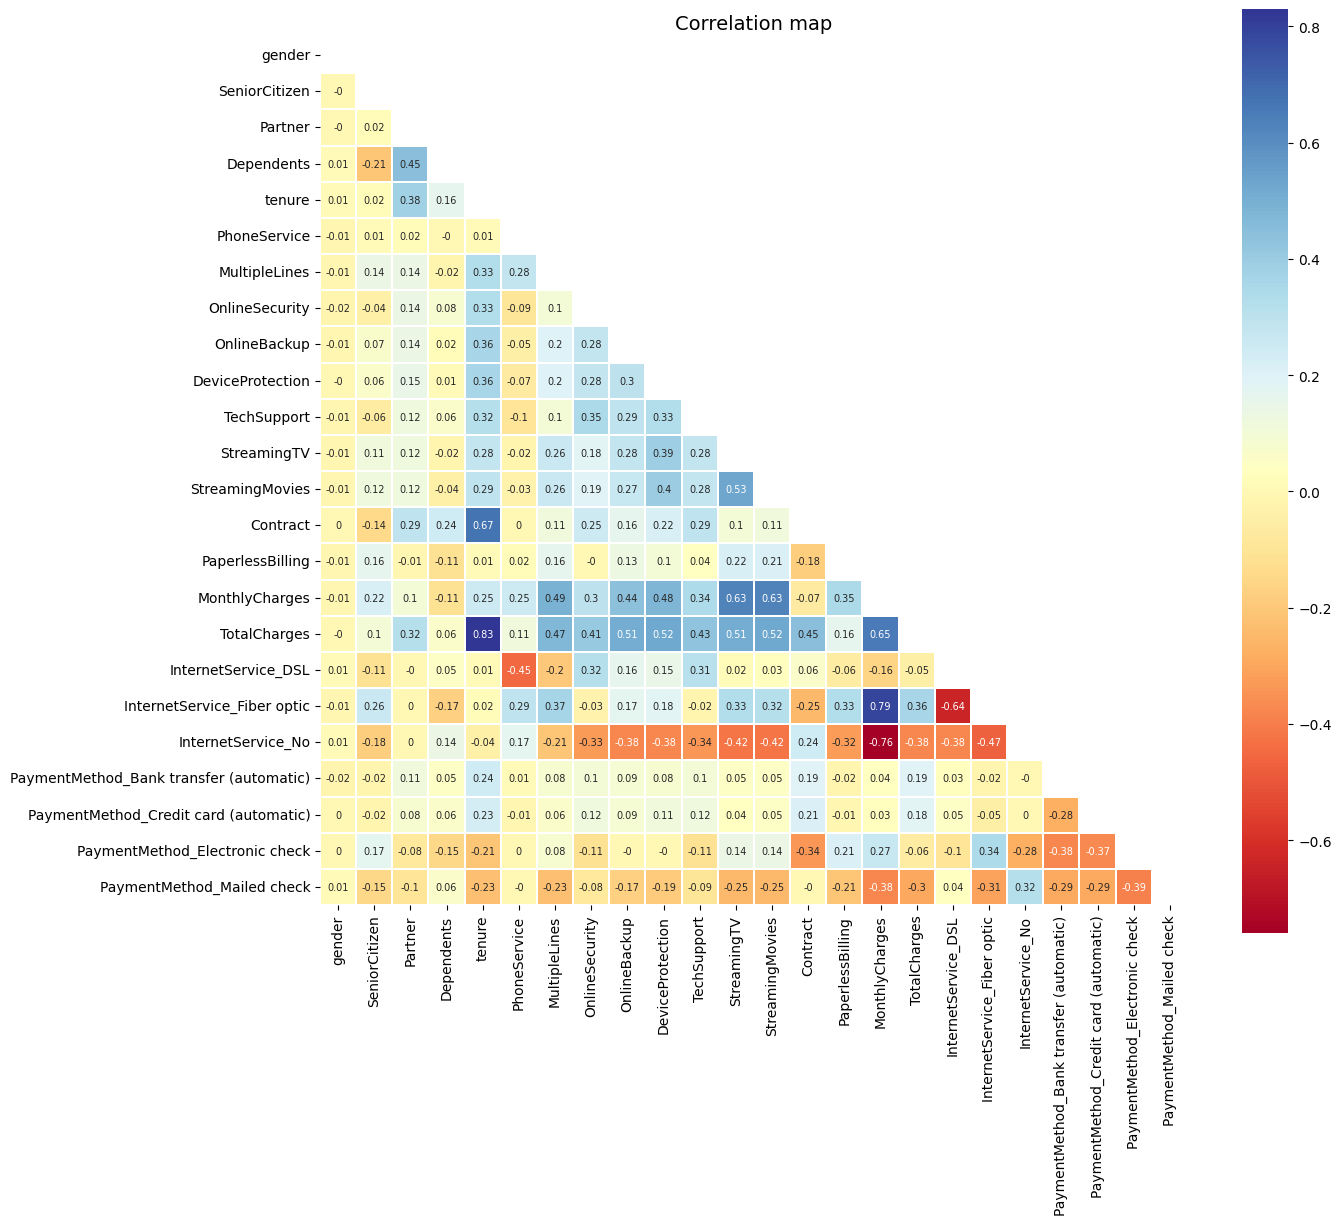

Contract                                  -0.396713
tenure                                    -0.352229
InternetService_No                        -0.227890
TotalCharges                              -0.198324
OnlineSecurity                            -0.171226
TechSupport                               -0.164674
Dependents                                -0.164221
Partner                                   -0.150448
PaymentMethod_Credit card (automatic)     -0.134302
InternetService_DSL                       -0.124214
PaymentMethod_Bank transfer (automatic)   -0.117937
PaymentMethod_Mailed check                -0.091683
OnlineBackup                              -0.082255
DeviceProtection                          -0.066160
gender                                    -0.008612
PhoneService                               0.011942
MultipleLines                              0.040102
StreamingMovies                            0.061382
StreamingTV                                0.063228
SeniorCitize

In [11]:
# correlation between all the columns
var_corr = round(features.corr(numeric_only=True), 2)

mask = np.triu(np.ones_like(var_corr, dtype=bool))   # hide the repeated top half

plt.figure(figsize=(14, 12))
sns.heatmap(var_corr, mask=mask, square=True, annot=True,
            annot_kws={'size': 7}, cmap='RdYlBu', linewidths=.1)
plt.title('Correlation map', fontsize=14)
plt.show()

# bonus: how much does each column relate to leaving (Churn)?
print(features.assign(Churn=labels).corr(numeric_only=True)['Churn'].sort_values())

In [12]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from google.colab import files
from sklearn.preprocessing import StandardScaler

# ---- Step 1: load the data ----
uploaded = files.upload()
filename = list(uploaded.keys())[0]
df = pd.read_csv(filename)

# ---- Step 3: split answer (labels) and clues (features) ----
labels = df['Churn']
features = df.drop(['Churn', 'customerID'], axis=1)

# ---- Step 4: fix TotalCharges (text -> number, blanks -> 0) ----
features['TotalCharges'] = pd.to_numeric(features['TotalCharges'], errors='coerce')
features['TotalCharges'] = features['TotalCharges'].fillna(0)

# ---- Step 5: merge "No phone/internet service" into "No" ----
cols_to_fix = ['MultipleLines', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
               'TechSupport', 'StreamingTV', 'StreamingMovies']
for col in cols_to_fix:
    features[col] = features[col].replace({'No phone service': 'No',
                                           'No internet service': 'No'})

# ---- Step 7: text -> numbers ----
yes_no_cols = ['Partner', 'Dependents', 'PhoneService', 'MultipleLines',
               'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
               'TechSupport', 'StreamingTV', 'StreamingMovies', 'PaperlessBilling']
for col in yes_no_cols:
    features[col] = features[col].map({'No': 0, 'Yes': 1})

features['gender'] = features['gender'].map({'Female': 0, 'Male': 1})
features['Contract'] = features['Contract'].map({'Month-to-month': 0,
                                                 'One year': 1,
                                                 'Two year': 2})
features = pd.get_dummies(features, columns=['InternetService', 'PaymentMethod'], dtype=int)
labels = labels.map({'No': 0, 'Yes': 1})

# ---- Step 8: drop TotalCharges (copy of tenure x MonthlyCharges) ----
features = features.drop('TotalCharges', axis=1)

# ---- Step 9: scale the two big-number columns ----
scaler = StandardScaler()
features[['tenure', 'MonthlyCharges']] = scaler.fit_transform(features[['tenure', 'MonthlyCharges']])

# ---- checks ----
print(features.shape)
print(features.isnull().sum().sum())
print(labels.value_counts())
print(features[['tenure', 'MonthlyCharges']].describe().round(2))

Saving customers.csv to customers (1).csv
(7043, 23)
0
Churn
0    5174
1    1869
Name: count, dtype: int64
        tenure  MonthlyCharges
count  7043.00         7043.00
mean     -0.00           -0.00
std       1.00            1.00
min      -1.32           -1.55
25%      -0.95           -0.97
50%      -0.14            0.19
75%       0.92            0.83
max       1.61            1.79


In [13]:
from sklearn.model_selection import train_test_split

features_train, features_test, labels_train, labels_test = train_test_split(
    features, labels, test_size=0.2, random_state=0, stratify=labels)

print(features.shape)
print(features_train.shape)
print(features_test.shape)
print(labels_train.value_counts(normalize=True).round(3))
print(labels_test.value_counts(normalize=True).round(3))


(7043, 23)
(5634, 23)
(1409, 23)
Churn
0    0.735
1    0.265
Name: proportion, dtype: float64
Churn
0    0.735
1    0.265
Name: proportion, dtype: float64
